<a href="https://colab.research.google.com/github/imaizumi0302/Urban_Vision/blob/main/Urban_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# フェーズ0:準備

## ライブラリインストール・モジュールインポート

In [1]:
# 必要なライブラリをインストール
!pip install ultralytics opencv-python-headless pandas
!pip uninstall -y fpdf
!pip uninstall -y PyFPDF


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.3 MB/s eta 0:00:00


In [2]:
pip install --upgrade fpdf2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.6/301.6 kB 18.3 MB/s eta 0:00:00


In [3]:
!wget -O NotoSansJP-Regular.otf https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansJP-Regular.otf


--2026-02-12 13:37:14--  https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansJP-Regular.otf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/notofonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansJP-Regular.otf [following]
--2026-02-12 13:37:14--  https://github.com/notofonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansJP-Regular.otf
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 404 Not Found
2026-02-12 13:37:15 ERROR 404: Not Found.



In [4]:
# Google Drive をマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# 2️ モジュールのインポート
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from google.colab.patches import cv2_imshow
from ultralytics import YOLO
from fpdf import FPDF

from moviepy.editor import VideoFileClip, ImageSequenceClip


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [6]:
# 最大列数を None（制限なし）に
pd.set_option('display.max_columns', None)

# 最大行数も None に
pd.set_option('display.max_rows', None)

In [7]:
!pip install -q yt-dlp


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.0/182.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 58.9 MB/s eta 0:00:00


In [8]:
!python -m yt_dlp --cookies /content/www.youtube.com_cookies.txt "https://www.youtube.com/watch?v=uOLXOKVGuAY"


[youtube] Extracting URL: https://www.youtube.com/watch?v=uOLXOKVGuAY
[youtube] uOLXOKVGuAY: Downloading webpage
[youtube] uOLXOKVGuAY: Downloading android vr player API JSON
[info] uOLXOKVGuAY: Downloading 1 format(s): 136+251
[download] Destination: Shibuya Crossing [uOLXOKVGuAY].f136.mp4
[download] 100% of   34.35MiB in 00:00:18 at 1.84MiB/s
[download] Destination: Shibuya Crossing [uOLXOKVGuAY].f251.webm
[download] 100% of    2.59MiB in 00:00:01 at 1.56MiB/s
[Merger] Merging formats into "Shibuya Crossing [uOLXOKVGuAY].mkv"
Deleting original file Shibuya Crossing [uOLXOKVGuAY].f251.webm (pass -k to keep)
Deleting original file Shibuya Crossing [uOLXOKVGuAY].f136.mp4 (pass -k to keep)


In [9]:
import torch
torch.cuda.is_available()


True

## 画像フォルダ解凍

実行方法：

本リポジトリの解析にはデータセット（ucsdpeds.zip）が必要です。

ご自身の環境に合わせて、以下の ZIP_PATH（zipの場所）と DEST_DIR（解凍先）を書き換えて実行してください。

In [10]:
# データセットの解凍設定
ZIP_PATH = "ucsdpeds.zip"
DEST_DIR = "/content/UCSD"
if os.path.exists(ZIP_PATH):
    !unzip {ZIP_PATH} -d {DEST_DIR}
else:
    print(f"Warning: {ZIP_PATH} が見つかりません。")

# 解凍したフォルダ（DEST_DIR）の中にある特定の動画フォルダを指定
frame_folder = os.path.join(DEST_DIR, "ucsdpeds/vidf/vidf1_33_009.y")

Streaming output truncated to the last 5000 lines.
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f072.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f102.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f010.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f019.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f109.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f142.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f027.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f001.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f174.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f079.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_f068.png  
 extracting: /content/UCSD/ucsdpeds/vidf/vidf4_33_011.y/vidf4_33_011_

## YOLOモデルのロード

In [11]:
# 3️YOLOモデルのロード
# 'yolov8n.pt' は軽量モデル
model = YOLO("yolov8n.pt")

# フェーズ1

##バウンディボックス表示

1枚の画像を読み込んで、その画像内にバウンディボックスと確信度を描画して表示


0: 448x640 14 persons, 67.9ms
Speed: 12.3ms preprocess, 67.9ms inference, 37.4ms postprocess per image at shape (1, 3, 448, 640)


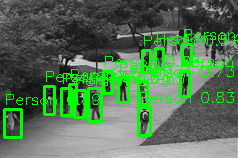

In [12]:
# 表示したいフレームのパス
# すでに定義済みの frame_folder を使ってファイル名を取得
frame_file = sorted(os.listdir(frame_folder))[0]  # 最初のフレーム
frame_path = os.path.join(frame_folder, frame_file)

# 画像読み込み
frame = cv2.imread(frame_path)

# YOLOで検出
results = model(frame)

# バウンディングボックス描画
for det in results:
    for box, cls, conf in zip(det.boxes.xyxy, det.boxes.cls, det.boxes.conf):
        if int(cls) == 0:  # personクラス
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)  # 緑色で枠
            cv2.putText(frame, f'Person {conf:.2f}', (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

# 画像表示
cv2_imshow(frame)
cv2.waitKey(0)
cv2.destroyAllWindows()


## 人数変化のグラフ描画

1フォルダ分(200枚)のフレームを読み込み、各フレームごとに人数をカウントし、その20秒間での人数の変化をグラフに描画

In [13]:
# フォルダ指定
frame_files = sorted(os.listdir(frame_folder))  # ファイル名順にソート
frame_file = sorted(os.listdir(frame_folder))[0]  # 最初のフレーム

results = []

for idx, file in enumerate(frame_files):
    frame_path = os.path.join(frame_folder, file)
    frame = cv2.imread(frame_path)  # 画像読み込み
    detections = model(frame)

    people_count = 0
    for det in detections:
        for cls in det.boxes.cls:
            if int(cls) == 0:  # personクラス
                people_count += 1

    results.append({"frame": idx, "time_sec": idx/10, "people_count": people_count})

df = pd.DataFrame(results)
df.to_csv("people_count_vidf1_33_009.csv", index=False)
print(df.head())



0: 448x640 14 persons, 6.9ms
Speed: 3.9ms preprocess, 6.9ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 6.1ms
Speed: 2.1ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 14 persons, 6.1ms
Speed: 2.0ms preprocess, 6.1ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 16 persons, 6.9ms
Speed: 1.8ms preprocess, 6.9ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 16 persons, 6.1ms
Speed: 2.3ms preprocess, 6.1ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 16 persons, 7.0ms
Speed: 1.5ms preprocess, 7.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 15 persons, 6.0ms
Speed: 2.3ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 6.5ms
Speed: 1.7ms preprocess, 6.5ms inference, 1.1ms postprocess per image at shape (1, 3, 44

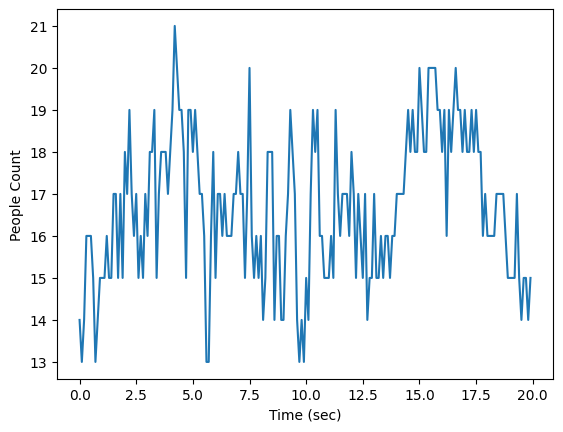

In [14]:
plt.plot(df["time_sec"], df["people_count"])
plt.xlabel("Time (sec)")
plt.ylabel("People Count")
plt.show()


# フェーズ2

## フレームから動画を生成

In [15]:
# フレーム画像フォルダ
frame_files = sorted(os.listdir(frame_folder))

# 動画出力先と設定
output_video = "video_from_frames.mp4"
fps = 10  # UCSDのフレームは10fpsなので10に設定

# 最初のフレームでサイズを取得
first_frame_path = os.path.join(frame_folder, frame_files[0])
frame = cv2.imread(first_frame_path)
height, width, layers = frame.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # MP4形式
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# 画像を順番に動画に書き込む
for file in frame_files:
    frame_path = os.path.join(frame_folder, file)
    img = cv2.imread(frame_path)
    out.write(img)

# 後処理
out.release()
print(f"完了！ {len(frame_files)} フレームから動画を作成しました: {output_video}")


完了！ 200 フレームから動画を作成しました: video_from_frames.mp4


## 混雑度スコア&バウンディボックス付き動画作成

In [16]:
# 混雑度スコアは簡易的に以下で定義
# 人数
# 0〜5 → Low（低混雑）
# 6〜15 → Medium（中混雑）
# 16人以上 → High（高混雑）

# 入力と出力
input_video = "video_from_frames.mp4"
output_video = "video_with_congestion_1.mp4"
csv_file = "congestion_results_1.csv"

# 動画を開く
cap = cv2.VideoCapture(input_video)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 出力設定
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

results_list = []
frame_idx = 0

def get_congestion_level_basic(count):
    """人数から混雑度スコアを返す"""
    if count <= 5:
        return "LOW", (0, 255, 0)   # 緑
    elif count <= 15:
        return "MEDIUM", (0, 255, 255)  # 黄色
    else:
        return "HIGH", (0, 0, 255)  # 赤

def get_congestion_level_advanced(count): #密度なども含めた最終的な混雑度計算用
    if count <= 5:
        return 1
    elif count <= 15:
        return 2
    else:
        return 3


def calc_density(boxes, frame_width, frame_height):
    frame_area = frame_width * frame_height
    total_area = 0

    for (x1, y1, x2, y2) in boxes:
        box_area = (x2 - x1) * (y2 - y1)
        total_area += box_area

    return total_area / frame_area

def IoU(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    if interArea == 0:
        return 0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return interArea / float(areaA + areaB - interArea)


def calc_overlap(boxes):
    if len(boxes) < 2:
        return 0

    total_iou = 0
    count = 0

    for i in range(len(boxes)):
        for j in range(i+1, len(boxes)):
            total_iou += IoU(boxes[i], boxes[j])
            count += 1

    return total_iou / count



while True:
    ret, frame = cap.read()
    if not ret:
        break

    # YOLO推論
    results = model(frame)

    people_count = 0  # フレーム内の人数

    # バウンディングボックス表示
    for det in results:
        for box, cls, conf in zip(det.boxes.xyxy, det.boxes.cls, det.boxes.conf):
            if int(cls) == 0:  # person クラス
                people_count += 1
                x1, y1, x2, y2 = map(int, box)

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 1)
                cv2.putText(frame, f'Person {conf:.2f}',
                            (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0,255,0), 1)

    density = calc_density(det.boxes.xyxy, width, height)
    overlap = calc_overlap(det.boxes.xyxy)

    # 混雑度スコア計算
    level, color = get_congestion_level_basic(people_count)



    # テキスト描画（人数 & 混雑度）
    cv2.putText(frame, f"Count: {people_count}",
                (10, 20), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255,255,255), 1)

    cv2.putText(frame, f"Congestion: {level}",
                (10, 35), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, color, 1)

    # フレーム書き込み
    out.write(frame)

    # 結果リストに記録（フレーム番号・時間・人数）
    results_list.append({"frame": frame_idx, "time_sec": frame_idx/fps, "people_count": people_count,"density":density,"overlap":overlap})

    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"{frame_idx} frames processed")

cap.release()
out.release()
print("完了！混雑度スコア付き動画の書き出しが終わりました！")



# CSV出力
df = pd.DataFrame(results_list)
df["congestion_score"] = df["people_count"].apply(get_congestion_level_advanced)
df["moving_avg"] = df["people_count"].rolling(window=10,min_periods = 1).mean()
df["change_rate"] = df["people_count"].diff().fillna(0)


scaler = MinMaxScaler()

df[["people_norm", "moving_norm", "change_norm", "density_norm", "overlap_norm"]] = \
    scaler.fit_transform(df[["people_count", "moving_avg", "change_rate", "density", "overlap"]])

df["final_score"] = (
    0.4 * df["moving_norm"] +
    0.2 * df["change_norm"] +
    0.2 * df["density_norm"] +
    0.2 * df["overlap_norm"]
)





df.to_csv(csv_file, index=False)
print(f"人数カウントCSVを保存しました: {csv_file}")



0: 448x640 12 persons, 8.2ms
Speed: 3.5ms preprocess, 8.2ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 7.6ms
Speed: 3.6ms preprocess, 7.6ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 15 persons, 8.1ms
Speed: 2.5ms preprocess, 8.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 17 persons, 7.5ms
Speed: 2.2ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 14 persons, 9.8ms
Speed: 2.0ms preprocess, 9.8ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 14 persons, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 7.7ms
Speed: 2.1ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 7.1ms
Speed: 2.2ms preprocess, 7.1ms inference, 1.3ms postprocess per image at shape (1, 3, 44

In [17]:
df.head()

,frame,time_sec,people_count,density,overlap,congestion_score,moving_avg,change_rate,people_norm,moving_norm,change_norm,density_norm,overlap_norm,final_score
0,0,0.0,12,"tensor(0.0791, device='cuda:0')",0.0,2,12.000000,0.0,0.2,0.000000,0.533333,0.387816,0.000000,0.184230
1,1,0.1,13,"tensor(0.0806, device='cuda:0')","tensor(0.0089, device='cuda:0')",2,12.500000,1.0,0.3,0.072464,0.600000,0.408894,0.404062,0.311577
2,2,0.2,15,"tensor(0.0924, device='cuda:0')","tensor(0.0065, device='cuda:0')",2,13.333333,2.0,0.5,0.193237,0.666667,0.576922,0.297325,0.385477
3,3,0.3,17,"tensor(0.1091, device='cuda:0')","tensor(0.0219, device='cuda:0')",3,14.250000,2.0,0.7,0.326087,0.666667,0.813399,1.000000,0.626448
4,4,0.4,14,"tensor(0.0925, device='cuda:0')","tensor(0.0011, device='cuda:0')",2,14.200000,-3.0,0.4,0.318841,0.333333,0.577346,0.052003,0.320073


# フェーズ3

- このフェーズでは、混雑スコアをブラッシュアップする
* 混雑スコアの定義
混雑スコア = 人数スコア× 重み + 密度 × 重み + 重なり度 × 重み  
※重みは、人数スコアを0.5とし、残りの0.5を密度と重なり度で分ける。  
※密度と重なり度の重みは主成分分析で算出  
※人数スコアは、人数を画面上に入る最大人数で割った値に係数をかけて算出する。  
今回は、係数は、0.25、画面上に入る最大人数は、画面の面積 ÷ 平均のバウンディボックス面積で算出  
※密度はバウンディボックスの面積の合計÷画面の面積  
※重なり度は、以下の手順で計算  
1. 2つのバウンディボックスの重なっている面積÷2つのバウンディボックスの合計の面積
2. 1を画面上の全組み合わせ分計算して、合計する。
3. 2で算出した合計値÷バウンディボックスの組み合わせ数 = 重なり度とする





## 主成分分析

In [18]:
# 結果リストからDataFrameを作成
df_PCA = pd.DataFrame(results_list)

# density と overlap を絶対値のまま使う
# PCA で重みを推定（density と overlap の重要度を自動調整）
pca = PCA(n_components=1)
pca.fit(df_PCA[["density", "overlap"]])
weights = pca.components_[0]
weights = weights / weights.sum()  # 合計1に正規化

w_density, w_overlap = weights
print(f"PCA推定の重み: density={w_density:.2f}, overlap={w_overlap:.2f}")

# final_score 計算
df_PCA["final_score"] = w_density * df["density"] + w_overlap * df["overlap"]

# LOW / MEDIUM / HIGH にカテゴリ化
def categorize(score):
    if score < 0.2:
        return "LOW"
    elif score < 0.5:
        return "MEDIUM"
    else:
        return "HIGH"

df["congestion_level"] = df["final_score"].apply(categorize)

# CSV 出力
csv_file = "congestion_results_PCA.csv"
df.to_csv(csv_file, index=False)
print(f"CSV保存完了: {csv_file}")


PCA推定の重み: density=0.87, overlap=0.13
CSV保存完了: congestion_results_PCA.csv


## 各種関数まとめ

すでに上のコードの中で、作成済みの関数が含まれていますが、改めてここで関数をまとめて記載します

In [19]:
# 混雑度カテゴリ化関数
def categorize(score):
    if score < 0.2:
        return "LOW", (0, 255, 0)
    elif score < 0.5:
        return "MEDIUM", (0, 255, 255)
    else:
        return "HIGH", (0, 0, 255)

# 密度計算関数
def calc_density(boxes, frame_w, frame_h):
    frame_area = frame_w * frame_h
    total_area = sum((x2-x1)*(y2-y1) for x1,y1,x2,y2 in boxes)
    return total_area / frame_area


# 重なり度計算関数(1フレームの中の人同士のバウンディボックスの重なり具合を計算する関数)
# 2人のバウンディボックスの面積の合計のうち重なってる部分の割合がどのくらいかを算出
def IoU(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(areaA + areaB - interArea)

# 重なり度合計関数
# 上記のIoU関数で計算した重なり度合の全組み合わせを合計し、全組み合わせ数で割る
# 重なり度は最大で1、最小で0
def calc_overlap(boxes):
    if len(boxes) < 2:
        return 0
    total_iou = 0
    count = 0
    for i in range(len(boxes)):
        for j in range(i+1, len(boxes)):
            total_iou += IoU(boxes[i], boxes[j])
            count += 1
    return total_iou / count

# グラフ作成関数
def make_graph_image(crowd_history, width):
    fig, ax = plt.subplots(figsize=(width/100, 1))  # 高さ100px
    ax.plot(crowd_history, label="Crowd Score", color='red')
    ax.legend(loc="upper left")
    ax.set_ylim(0, max(1, max(crowd_history)))
    fig.tight_layout()

    # RGBA画像として取得
    fig.canvas.draw()
    graph = np.frombuffer(fig.canvas.renderer.buffer_rgba(), dtype=np.uint8)
    graph = graph.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    graph = cv2.cvtColor(graph, cv2.COLOR_RGBA2BGR)  # BGRに変換

    plt.close(fig)
    graph = cv2.resize(graph, (width, 100))
    return graph

## 混雑度スコア、ヒートマップ、グラフ、人数カウント組み込み動画

In [20]:
# ===============================
# モデル読み込み（例）
# ===============================
model = YOLO("yolov8n.pt")

# ===============================
# 動画入力・出力設定
# ===============================
input_video = "video_from_frames.mp4"
output_video = "video_with_congestion_2.mp4"
csv_file = "congestion_results_2.csv"


cap = cv2.VideoCapture(input_video)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height+100))  # グラフ分追加

# ===============================
# 結果格納リスト
# ===============================
results_list = []

# ===============================
# ヒートマップ用フレーム
# ===============================
heatmap_accum = np.zeros((height, width), dtype=np.float32)

# ===============================
# 重み設定
# ===============================
w_people = 0.5
w_density = w_density * 0.5
w_overlap = w_overlap * 0.5

# ===============================
# フレームインデックス
# ===============================
frame_idx = 0


# ===============================
# メインループ
# ===============================
crowd_history = []
count_history = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    results = model(frame)
    people_count = 0
    boxes_list = []

    for det in results:
        for box, cls, conf in zip(det.boxes.xyxy, det.boxes.cls, det.boxes.conf):
            if int(cls) == 0:  # person
                people_count += 1
                x1, y1, x2, y2 = map(int, box)
                boxes_list.append((x1,y1,x2,y2))
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 1)
                cv2.putText(frame, f'{conf:.2f}', (x1,y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0,255,0), 1)
                heatmap_accum[y1:y2, x1:x2] += 1

    density = calc_density(boxes_list, width, height)
    overlap = calc_overlap(boxes_list)

    if len(boxes_list) > 0:
        avg_box_area = sum((x2-x1)*(y2-y1) for x1,y1,x2,y2 in boxes_list)/len(boxes_list)
    else:
        avg_box_area = 1
    max_people = (width*height)/avg_box_area*0.25
    people_score = min(people_count/max_people, 1.0)

    final_score = w_people*people_score + w_density*density + w_overlap*overlap
    level, color = categorize(final_score)

    cv2.putText(frame, f"Count: {people_count}", (10,20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255),1)
    cv2.putText(frame, f"Congestion: {level} ({final_score*100:.1f}%)", (10,35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    # ヒートマップ描画
    heatmap_normalized = np.clip(heatmap_accum/heatmap_accum.max(),0,1)
    heatmap_color = cv2.applyColorMap((heatmap_normalized*255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(frame, 0.7, heatmap_color, 0.3, 0)

    # 履歴に追加
    crowd_history.append(final_score*100)
    count_history.append(people_count)

    # グラフ作成
    graph_img = make_graph_image(crowd_history[-100:], w)

    # 縦に合成
    combined = np.vstack([overlay, graph_img])
    out.write(combined)


    # 結果リスト記録
    results_list.append({
        "frame": frame_idx,
        "time_sec": frame_idx/fps,
        "people_count": people_count,
        "density": density,
        "overlap": overlap,
        "people_score": people_score,
        "final_score": final_score,
        "congestion_level": level
    })

    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"{frame_idx} frames processed")



cap.release()
out.release()
cv2.destroyAllWindows()

# CSV出力
df = pd.DataFrame(results_list)
df.to_csv(csv_file, index=False)
print(f"CSV保存完了: {csv_file}")


0: 448x640 12 persons, 6.6ms
Speed: 1.4ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 8.0ms
Speed: 2.3ms preprocess, 8.0ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 15 persons, 6.3ms
Speed: 2.2ms preprocess, 6.3ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 17 persons, 6.5ms
Speed: 1.7ms preprocess, 6.5ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 14 persons, 6.1ms
Speed: 1.8ms preprocess, 6.1ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 14 persons, 6.3ms
Speed: 2.0ms preprocess, 6.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 8.5ms
Speed: 2.3ms preprocess, 8.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 6.0ms
Speed: 2.1ms preprocess, 6.0ms inference, 1.2ms postprocess per image at shape (1, 3, 44

In [21]:
df.head()

,frame,time_sec,people_count,density,overlap,people_score,final_score,congestion_level
0,0,0.0,12,0.079380,0.000000,0.317519,0.193357,LOW
1,1,0.1,13,0.079167,0.008629,0.316668,0.193392,LOW
2,2,0.2,15,0.092889,0.006375,0.371556,0.226672,MEDIUM
3,3,0.3,17,0.108712,0.021341,0.434847,0.266174,MEDIUM
4,4,0.4,14,0.095389,0.001091,0.381555,0.232422,MEDIUM


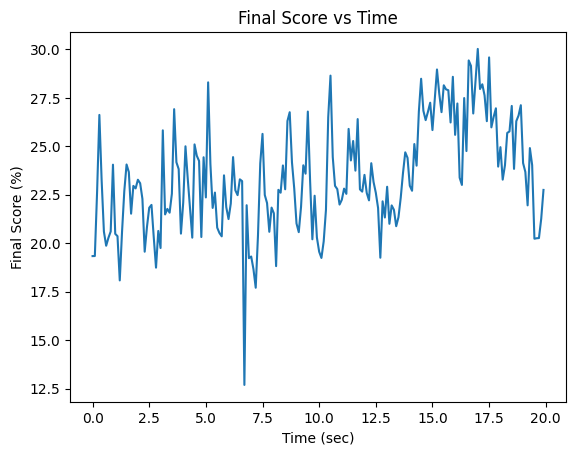

In [22]:
plt.plot(df["time_sec"], df["final_score"]*100)
plt.xlabel("Time (sec)")
plt.ylabel("Final Score (%)")
plt.title("Final Score vs Time")
plt.show()

## ピーク検出＆フレーム抽出機能付きコード

### ピーク検出＆フレーム抽出用関数

In [23]:
# ================================
# 1. ピーク検出関数
# ================================
def detect_peaks(scores, threshold=0.2, distance=10):
    peaks = []
    length = len(scores)

    for i in range(1, length-1):
        if scores[i] > scores[i-1] and scores[i] > scores[i+1]:
            if scores[i] >= threshold:       # 最低スコア
                if len(peaks) == 0 or (i - peaks[-1]) >= distance:  # 最低離隔
                    peaks.append(i)

    return peaks


# ==================================================
# 2. ピークに対応するフレーム画像を保存する関数
# ==================================================
def save_peak_frames(frames_buffer, peaks, time_list, score_list, output_dir="peak_frames"):
    os.makedirs(output_dir, exist_ok=True)

    saved_paths = []

    for idx in peaks:
        frame = frames_buffer[idx]
        sec = time_list[idx]
        score = score_list[idx]

        filename = f"peak_{sec:.1f}s_score{score:.2f}.jpg"
        filepath = os.path.join(output_dir, filename)

        cv2.imwrite(filepath, frame)
        saved_paths.append(filepath)

        print(f"ピーク検出 → {filepath}")

    return saved_paths


In [24]:
# ===============================
# モデル読み込み
# ===============================
model = YOLO("yolov8n.pt")

# ===============================
# 動画入力・出力設定
# ===============================
input_video = "video_from_frames.mp4"
output_video = "video_with_congestion_3.mp4"
csv_file = "congestion_results_3.csv"


cap = cv2.VideoCapture(input_video)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height+100))  # グラフ分追加

# ===============================
# 各種格納リスト
# ===============================
results_list = []
frames_buffer = []       # フレーム保存
crowd_history = []       # final_score 保存
time_history = []        # 秒数保存
count_history = []

# ===============================
# ヒートマップ用フレーム
# ===============================
heatmap_accum = np.zeros((height, width), dtype=np.float32)

# ===============================
# 重み設定
# ===============================
w_people = 0.5
w_density = w_density * 0.5
w_overlap = w_overlap * 0.5

# ===============================
# フレームインデックス
# ===============================
frame_idx = 0

# ===============================
# メインループ
# ===============================

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    results = model(frame)
    people_count = 0
    boxes_list = []

    for det in results:
        for box, cls, conf in zip(det.boxes.xyxy, det.boxes.cls, det.boxes.conf):
            if int(cls) == 0:  # person
                people_count += 1
                x1, y1, x2, y2 = map(int, box)
                boxes_list.append((x1,y1,x2,y2))
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 1)
                cv2.putText(frame, f'{conf:.2f}', (x1,y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0,255,0), 1)
                heatmap_accum[y1:y2, x1:x2] += 1

    density = calc_density(boxes_list, width, height)
    overlap = calc_overlap(boxes_list)

    if len(boxes_list) > 0:
        avg_box_area = sum((x2-x1)*(y2-y1) for x1,y1,x2,y2 in boxes_list)/len(boxes_list)
    else:
        avg_box_area = 1
    max_people = (width*height)/avg_box_area*0.25
    people_score = min(people_count/max_people, 1.0)

    final_score = w_people*people_score + w_density*density + w_overlap*overlap
    level, color = categorize(final_score)

    cv2.putText(frame, f"Count: {people_count}", (10,20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255),1)
    cv2.putText(frame, f"Congestion: {level} ({final_score*100:.1f}%)", (10,35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    # ヒートマップ描画
    heat_max = max(heatmap_accum.max(), 1)
    heatmap_normalized = np.clip(heatmap_accum / heat_max, 0, 1)
    heatmap_color = cv2.applyColorMap((heatmap_normalized*255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(frame, 0.7, heatmap_color, 0.3, 0)

    # 履歴に追加
    frames_buffer.append(overlay.copy())  # ← 上の完成フレームを保存
    time_history.append(frame_idx/fps)
    count_history.append(people_count)
    crowd_history.append(final_score)


    # グラフ作成
    graph_img = make_graph_image(crowd_history[-100:], w)

    # 縦に合成
    combined = np.vstack([overlay, graph_img])
    out.write(combined)


    # 結果リスト記録
    results_list.append({
        "frame": frame_idx,
        "time_sec": frame_idx/fps,
        "people_count": people_count,
        "density": density,
        "overlap": overlap,
        "people_score": people_score,
        "final_score": final_score,
        "congestion_level": level
    })

    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"{frame_idx} frames processed")



cap.release()
out.release()
cv2.destroyAllWindows()

print("\n=== ピーク検出開始 ===")

crowd_arr = np.array(crowd_history)

# ピーク検出（例：スコア 0.6以上 & 最低10フレーム離隔）
peak_idxs = detect_peaks(crowd_arr, threshold=0.2, distance=10)

print("検出されたピーク index:", peak_idxs)

# ピークフレーム保存
saved = save_peak_frames(
    frames_buffer,
    peak_idxs,
    time_history,
    crowd_history,
    output_dir="peak_frames"
)

print("\n=== ピーク抽出完了 ===")
print("保存されたファイル一覧:")
for s in saved:
    print(" -", s)


# CSV出力
df = pd.DataFrame(results_list)
df.to_csv(csv_file, index=False)
print(f"CSV保存完了: {csv_file}")



0: 448x640 12 persons, 6.6ms
Speed: 1.4ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 6.2ms
Speed: 2.3ms preprocess, 6.2ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 15 persons, 6.4ms
Speed: 2.0ms preprocess, 6.4ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 17 persons, 7.3ms
Speed: 2.4ms preprocess, 7.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 14 persons, 6.5ms
Speed: 1.7ms preprocess, 6.5ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 14 persons, 6.3ms
Speed: 2.5ms preprocess, 6.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 11.2ms
Speed: 2.3ms preprocess, 11.2ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 13 persons, 9.8ms
Speed: 2.4ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 

## ピーク前後の3秒クリップ生成

In [25]:
clip_seconds = 3
highlight_frames = []

video = VideoFileClip(input_video)
fps = video.fps

for idx in peak_idxs:
    peak_time = time_history[idx]
    start_time = max(peak_time - clip_seconds, 0)
    end_time = min(peak_time + clip_seconds, video.duration)

    n_frames = int((end_time - start_time) * fps)

    for i in range(n_frames):
        t = start_time + i/fps
        frame = video.get_frame(t).copy()

        frame_idx_in_full = min(int(round(t*fps)), len(crowd_history)-1)
        current_score = crowd_history[frame_idx_in_full]
        current_count = count_history[frame_idx_in_full]

        texts = [
            f"Time: {t:.2f}s",
            f"Score: {current_score:.2f}",
            f"Count: {current_count}"
        ]

        for j, text in enumerate(texts):
            cv2.putText(frame, text, (30, frame.shape[0]-10-j*20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255,255,0), 1, cv2.LINE_AA)

        highlight_frames.append(frame)

# ImageSequenceClip で動画作成
highlight_video = "peak_highlights.mp4"
clip = ImageSequenceClip([cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in highlight_frames], fps=fps)
clip.write_videofile(highlight_video, codec="libx264")
print(f"ピークハイライト動画保存 → {highlight_video}")


Moviepy - Building video peak_highlights.mp4.
Moviepy - Writing video peak_highlights.mp4



Moviepy - Done !
Moviepy - video ready peak_highlights.mp4
ピークハイライト動画保存 → peak_highlights.mp4


In [26]:
plt.figure(figsize=(10,3))
plt.plot(crowd_history, label="Crowd Score")
plt.xlabel("Frame")
plt.ylabel("Score")
plt.title("Crowd Summary")
plt.legend()
plt.tight_layout()
plt.savefig("summary_graph.png")
plt.close()


In [27]:
# PDF生成
pdf = FPDF()
pdf.add_page()

# フォント設定
pdf.set_font("Arial", "B", 16)

# タイトル
pdf.cell(0, 10, "Crowd Summary", ln=True, align="C")

# グラフ画像貼り付け
summary_graph = "summary_graph.png"  # あらかじめ保存してあるグラフ画像
if os.path.exists(summary_graph):
    pdf.image(summary_graph, x=10, y=30, w=pdf.w-20)
else:
    print(f"Warning: {summary_graph} not found.")

# Peak List
pdf.set_font("Arial", "", 12)
pdf.set_y(140)  # グラフの下あたりから開始
pdf.cell(0, 10, "Peak List:", ln=True)


line_height = 8
for idx in peak_idxs:
    pdf.cell(0, line_height, f"- Time: {time_history[idx]:.2f}s, Score: {crowd_history[idx]:.2f}", ln=True)

# PDF保存
pdf_file = "crowd_summary.pdf"
pdf.output(pdf_file)
print(f"Crowd summary PDF saved → {pdf_file}")


  pdf.set_font("Arial", "B", 16)

  pdf.cell(0, 10, "Crowd Summary", ln=True, align="C")

  pdf.set_font("Arial", "", 12)

  pdf.cell(0, 10, "Peak List:", ln=True)

  pdf.cell(0, line_height, f"- Time: {time_history[idx]:.2f}s, Score: {crowd_history[idx]:.2f}", ln=True)



Crowd summary PDF saved → crowd_summary.pdf


In [28]:


# # ------------------------------
# # 動画パス
# # ------------------------------
# youtube_video_path = "/content/Shibuya Crossing [uOLXOKVGuAY].mp4"

# # 前後何秒をハイライトにするか
# clip_seconds = 3

# video = VideoFileClip(youtube_video_path)
# fps = video.fps
# peak_clips = []

# # peak_idxs, time_history, crowd_history は
# # すでに解析済みのものを使用
# for idx in peak_idxs:
#     peak_time = time_history[idx]
#     start_time = max(peak_time - clip_seconds, 0)
#     end_time = min(peak_time + clip_seconds, video.duration)

#     subclip = video.subclip(start_time, end_time)

#     # ------------------------------
#     # フレーム上に人数・スコアを描画
#     # ------------------------------
#     def annotate_frame(get_frame, t):
#         frame = get_frame(t).copy()
#         current_time = start_time + t
#         frame_idx = min(int(current_time * fps), len(crowd_history)-1)
#         score = crowd_history[frame_idx]
#         count = count_history[frame_idx]

#         texts = [
#             f"Time: {current_time:.2f}s",
#             f"Score: {score:.2f}",
#             f"Count: {count}"
#         ]

#         font_scale = 0.5
#         thickness = 1
#         line_height = 20

#         for i, text in enumerate(texts):
#             cv2.putText(frame, text, (30, frame.shape[0]-10-i*line_height),
#                         cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255,255,0), thickness, cv2.LINE_AA)
#         return frame

#     annotated_clip = subclip.fl(annotate_frame, apply_to=['mask', 'video'])
#     peak_clips.append(annotated_clip)

# # ------------------------------
# # ハイライト動画作成
# # ------------------------------
# highlight_video = "youtube_peak_highlights.mp4"
# final_clip = concatenate_videoclips(peak_clips)
# final_clip.write_videofile(highlight_video, codec="libx264")
# print(f"ハイライト動画保存 → {highlight_video}")


In [29]:
# cap = cv2.VideoCapture("/content/Shibuya Crossing [uOLXOKVGuAY].mp4")
# print(int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
# cap.release()


In [30]:
# video_path = "/content/Shibuya Crossing [uOLXOKVGuAY].mp4"

# cap = cv2.VideoCapture(video_path)

# fps = cap.get(cv2.CAP_PROP_FPS)
# total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
# duration = total_frames / fps if fps > 0 else 0

# print("🎥 FPS:", fps)
# print("📌 総フレーム数:", total_frames)
# print("⏳ 動画の長さ（秒）:", duration)


In [31]:
# # ===============================
# # モデル読み込み
# # ===============================
# model = YOLO("yolov8n.pt")


# # ===============================
# # 動画入力・出力設定
# # ===============================
# input_video = "/content/Shibuya Crossing [uOLXOKVGuAY].mp4"
# output_video = "shibuya_congestion_full.mp4"

# cap = cv2.VideoCapture(input_video)
# fps = int(cap.get(cv2.CAP_PROP_FPS))

# # 元動画は 1280x720 → メモリ節約のため縮小
# target_w, target_h = 640, 360

# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# out = cv2.VideoWriter(output_video, fourcc, fps, (target_w, target_h + 100))


# # ===============================
# # 履歴
# # ===============================
# results_list = []
# crowd_history = []
# time_history = []
# count_history = []


# # ===============================
# # ヒートマップ
# # ===============================
# heatmap_accum = np.zeros((target_h, target_w), dtype=np.float32)


# # ===============================
# # 重み
# # ===============================
# w_people = 0.5
# w_density = 0.3
# w_overlap = 0.2

# # ===============================
# # メインループ
# # ===============================
# frame_idx = 0

# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break

#     # サイズ縮小（RAM節約 + 推論高速化）
#     frame = cv2.resize(frame, (target_w, target_h))

#     # YOLO 推論（GPUで高速実行）
#     results = model.predict(
#         frame,
#         device="cuda:0",
#         imgsz=320,
#         classes=[0],
#         conf=0.3,
#         iou=0.5,
#         verbose=False
#     )

#     det = results[0]
#     boxes = det.boxes.xyxy.cpu().numpy() if det.boxes is not None else []

#     people_count = len(boxes)
#     boxes_list = []

#     for box in boxes:
#         x1, y1, x2, y2 = map(int, box)
#         boxes_list.append((x1, y1, x2, y2))
#         cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 1)

#         heatmap_accum[y1:y2, x1:x2] += 1


#     # ===============================
#     # スコア計算
#     # ===============================
#     density = calc_density(boxes_list, target_w, target_h)
#     overlap = calc_overlap(boxes_list)
#     avg_box = np.mean([(x2-x1)*(y2-y1) for x1,y1,x2,y2 in boxes_list]) if boxes_list else 1
#     max_people = (target_w*target_h) / avg_box * 0.25
#     people_score = min(people_count / max_people, 1.0)

#     final_score = w_people*people_score + w_density*density + w_overlap*overlap
#     level, color = categorize(final_score)


#     # ===============================
#     # ヒートマップ生成
#     # ===============================
#     heat_norm = heatmap_accum / max(heatmap_accum.max(), 1)
#     heat_color = cv2.applyColorMap((heat_norm*255).astype(np.uint8), cv2.COLORMAP_JET)
#     overlay = cv2.addWeighted(frame, 0.7, heat_color, 0.3, 0)


#     # ===============================
#     # グラフ合成
#     # ===============================
#     crowd_history.append(final_score)
#     graph_img = make_graph_image(crowd_history, target_w)
#     combined = np.vstack([overlay, graph_img])

#     out.write(combined)


#     # ===============================
#     # CSV 用データ保存
#     # ===============================
#     results_list.append({
#         "frame": frame_idx,
#         "time_sec": frame_idx/fps,
#         "people_count": people_count,
#         "density": density,
#         "overlap": overlap,
#         "people_score": people_score,
#         "final_score": final_score,
#         "level": level
#     })

#     frame_idx += 1
#     if frame_idx % 50 == 0:
#         print(f"{frame_idx} frames processed")

# cap.release()
# out.release()
# cv2.destroyAllWindows()


# # ===============================
# # CSV 出力
# # ===============================
# pd.DataFrame(results_list).to_csv("shibuya_congestion_results.csv", index=False)
# print("🎉 完了：CSV出力しました！")
